## Create a new environment in bioconda (miniconda)

In [1]:
!conda create -n its-nanopore -c bioconda -c conda-forge nanoplot cutadapt chopper emu osfclient -y
!conda activate its-nanopore

2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/marcos/miniconda3/envs/its-nanopore

  added / updated specs:
    - chopper
    - cutadapt
    - emu
    - nanoplot
    - osfclient


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    clang-22.1.8               |default_cfg_h9b3f985_5          33 KB  conda-forge
    clang-22-22.1.8            |default_h982d582_5         916 KB  conda-forge
    clang_impl_linux-64-22.1.8 |default_h52fce35_5          33 KB  conda-forge
    libarrow-25.0.0            |   hcc2f0d9_4_cpu         6.3 MB  conda-forge
    libarrow-acero-25.0.0      |

In [2]:
# Sanity check using 'conda run' to point to the correct environment
!conda run -n its-nanopore NanoPlot --version
!conda run -n its-nanopore cutadapt --version
!conda run -n its-nanopore chopper --version
!conda run -n its-nanopore emu --version

NanoPlot 1.47.1
5.2
chopper 0.13.0
emu v3.6.2


## Renamed

In [3]:
import os
import shutil
import pandas as pd

# 1. Paths
folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its'
csv_file = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/meta_date_its.csv'
renamed_folder = os.path.join(folder, 'renamed')  # raw files stay untouched
os.makedirs(renamed_folder, exist_ok=True)

# 2. Read metadata (comma is the expected separator for a .csv)
df = pd.read_csv(csv_file, sep=',')
assert {'Name', 'sample_title'}.issubset(df.columns), f"Missing columns, found: {df.columns.tolist()}"

dupes = df['sample_title'][df['sample_title'].duplicated()].tolist()
if dupes:
    raise ValueError(f"Duplicate sample_title values would overwrite files: {dupes}")

log = []

# 3. Copy files under the new name, preserving the original extension
for _, row in df.iterrows():
    old_name = str(row['Name']).strip()
    sample_title = str(row['sample_title']).strip()
    old_path = os.path.join(folder, old_name)

    if not os.path.exists(old_path):
        print(f"[ERROR] File not found: {old_name}")
        continue

    if old_name.endswith('.fastq.gz'):
        ext = '.fastq.gz'
    elif old_name.endswith('.fastq'):
        ext = '.fastq'
    else:
        ext = os.path.splitext(old_name)[1]

    new_name = f"{sample_title}{ext}"
    new_path = os.path.join(renamed_folder, new_name)

    shutil.copy2(old_path, new_path)
    log.append({'old_name': old_name, 'new_name': new_name})
    print(f"[SUCCESS] Copied: {old_name} -> {new_name}")

pd.DataFrame(log).to_csv(os.path.join(renamed_folder, 'rename_manifest.csv'), index=False)
print("Done!")

[SUCCESS] Copied: Controle-1_ITS.fastq -> CTL-1.fastq
[SUCCESS] Copied: Controle-2_ITS.fastq -> CTL-2.fastq
[SUCCESS] Copied: Controle-3_ITS.fastq -> CTL-3.fastq
[SUCCESS] Copied: Desn-1_ITS.fastq -> DES-1.fastq
[SUCCESS] Copied: Desn-2_ITS.fastq -> DES-2.fastq
[SUCCESS] Copied: Desn-3_ITS.fastq -> DES-3.fastq
[SUCCESS] Copied: M-Desn-1_ITS.fastq -> MOT-1.fastq
[SUCCESS] Copied: M-Desn-2_ITS.fastq -> MOT-2.fastq
[SUCCESS] Copied: M-Desn-3_ITS.fastq -> MOT-3.fastq
[SUCCESS] Copied: P-Desn-1_ITS.fastq -> FAT-1.fastq
[SUCCESS] Copied: P-Desn-2_ITS.fastq -> FAT-2.fastq
[SUCCESS] Copied: P-Desn-3_ITS.fastq -> FAT-3.fastq
Done!


## Library and directory preparation

In [4]:
import os
import subprocess

# 1. Paths configuration (Updating based on your previous paths)
renamed_folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its/renamed'
base_out = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its'

# Define specific output folders for each step
qc_dir = os.path.join(base_out, '1_qc_raw')
trimmed_dir = os.path.join(base_out, '2_trimmed')
filtered_dir = os.path.join(base_out, '3_filtered')
emu_dir = os.path.join(base_out, '4_emu_taxa')

# Create directories if they don't exist
for directory in [qc_dir, trimmed_dir, filtered_dir, emu_dir]:
    os.makedirs(directory, exist_ok=True)

# 2. Get list of renamed files
fastq_files = [f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')]
print(f"Found {len(fastq_files)} fastq files to process.")

Found 12 fastq files to process.


## Quality control of the reads

In [6]:
from pathlib import Path
import subprocess

env = "its-nanopore"
threads = "4"

renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its/renamed")
qc_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_raw")
qc_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    f"conda install -n {env} -c bioconda -c conda-forge multiqc nanocomp -y",
    shell=True,
    check=True
)

fastq_files = sorted(
    file for file in renamed_folder.iterdir()
    if file.name.endswith((".fastq", ".fastq.gz"))
)

print(f"Starting QC for {len(fastq_files)} samples...")

for file in fastq_files:
    sample = file.name.split(".fastq")[0]
    print(f"Running NanoPlot: {sample}")

    subprocess.run([
        "conda", "run", "-n", env, "NanoPlot",
        "-t", threads, "--fastq", str(file),
        "-o", str(qc_dir / sample)
    ], check=True)

nanocomp_out = qc_dir / "NanoComp_Report"
nanocomp_out.mkdir(exist_ok=True)

print("Generating NanoComp report...")
subprocess.run([
    "conda", "run", "-n", env, "NanoComp", "-t", threads,
    "--fastq", *map(str, fastq_files),
    "--names", *(file.name.split(".fastq")[0] for file in fastq_files),
    "-o", str(nanocomp_out)
], check=True)

multiqc_out = qc_dir / "MultiQC_Report"

print("Generating MultiQC report...")
subprocess.run([
    "conda", "run", "-n", env, "multiqc",
    str(qc_dir), "-o", str(multiqc_out)
], check=True)

print("\nQuality control completed!")
print(f"MultiQC report: {multiqc_out / 'multiqc_report.html'}")
print(f"NanoComp report: {nanocomp_out}")

2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda





# All requested packages already installed.

Starting QC for 12 samples...
Running NanoPlot: CTL-1
Running NanoPlot: CTL-2
Running NanoPlot: CTL-3
Running NanoPlot: DES-1
Running NanoPlot: DES-2
Running NanoPlot: DES-3
Running NanoPlot: FAT-1
Running NanoPlot: FAT-2
Running NanoPlot: FAT-3
Running NanoPlot: MOT-1
Running NanoPlot: MOT-2
Running NanoPlot: MOT-3
Generating NanoComp report...
Generating MultiQC report...

Quality control completed!
MultiQC report: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_raw/MultiQC_Report/multiqc_report.html
NanoComp report: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_raw/NanoComp_Report



/// ]8;id=10896356;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     version_check | MultiQC Version v1.35 now available!
       file_search | Search path: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_raw

       ⠋ searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0/239  
       searching |  18% 42/239 1_qc_raw/CTL-2/LengthvsQualityScatterPlot_dot.ht…
       searching |  5… 130/239 /its/1_qc_raw/NanoComp_Report/NanoComp-report.ht…
       searching |  8… 212/239 downstream/its/1_qc_raw/DES-1/NanoPlot-report.ht…
         searching | ━━━━━━━━━━━━���━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 239/239  
          nanostat | Found 2 reports
     write_results | Data        : colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_raw/MultiQC_Report/multiqc_data
     write_results | Report      : colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAM

## Remove primers

In [ ]:
import os
import gzip

# Pathway to the renamed folder containing FASTQ files
renamed_folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its/renamed'

# Primers to check
primers_to_check = {
    "27F (Standard)": "AGRGTTYGATYMTGGCTCAG",
    "515F (V4)": "GTGYCAGCMGCCGCGGTAA",
    "1492R (Standard)": "RGYTACCTTGTTACGACTT"
}

sample_files = [f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')]
test_file = os.path.join(renamed_folder, sample_files[0])

print(f"Processing sample: {sample_files[0]}\n")

# Read the first 1000 sequences from the FASTQ file
sequences = []
open_func = gzip.open if test_file.endswith('.gz') else open
with open_func(test_file, 'rt') as f:
    for i, line in enumerate(f):
        if i % 4 == 1:  # Line of the DNA sequence in the FASTQ file
            sequences.append(line.strip())
        if len(sequences) >= 1000:
            break

# Count how many times the primer fragments appear at the beginning of the reads
for name, primer in primers_to_check.items():
    # Get the first 15 nucleotides of the primer for partial search
    primer_snippet = primer[:15].replace('R', 'A').replace('Y', 'C').replace('M', 'A').replace('T', 'T')
    matches = sum(1 for seq in sequences if primer_snippet in seq[:30])
    print(f"Primer {name}: Found in {matches} of 1000 tested reads.")

In [ ]:
import os
import subprocess

subprocess.run("conda install -n its-nanopore -c bioconda cutadapt -y", shell=True, check=True, stdout=subprocess.DEVNULL)

renamed_folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its/renamed'
trimmed_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/2_trimmed'

os.makedirs(trimmed_dir, exist_ok=True)

fastq_files = [f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')]

# 4. Run Cutadapt to remove 16S primers
# Replace these sequences with the exact primers used by the sequencing company
primer_f = "AGRGTTYGATYMTGGCTCAG" # Example: 27F
primer_r = "RGYTACCTTGTTACGACTT"  # Example: 1492R

print("Starting Primer Trimming with cutadapt...")

for file in fastq_files:
    sample_name = file.split('.fastq')[0]
    input_path = os.path.join(renamed_folder, file)
    output_path = os.path.join(trimmed_dir, file) # keeping original extension
    
    cmd = [
        "conda", "run", "-n", "its-nanopore",
        "cutadapt",
        "-g", primer_f,      # Forward primer
        "-a", primer_r,      # Reverse primer
        "-e", "0.15",        # Allowed error rate
        # "--discard-untrimmed", # Optional: throw away reads that don't have primers
        "-o", output_path,
        input_path
    ]
    
    print(f"Trimming {sample_name}...")
    subprocess.run(cmd, check=True)

print("Trimming finished!")

In [ ]:
from pathlib import Path
import subprocess

env = "its-nanopore"
threads = "4"

renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/2_trimmed")
qc_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_trimmed")
qc_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    f"conda install -n {env} -c bioconda -c conda-forge multiqc nanocomp -y",
    shell=True,
    check=True
)

fastq_files = sorted(
    file for file in renamed_folder.iterdir()
    if file.name.endswith((".fastq", ".fastq.gz"))
)


for file in fastq_files:
    sample = file.name.split(".fastq")[0]
    subprocess.run([
        "conda", "run", "-n", env, "NanoPlot",
        "-t", threads, "--fastq", str(file),
        "-o", str(qc_dir / sample)
    ], check=True)
nanocomp_out = qc_dir / "NanoComp_Report"
nanocomp_out.mkdir(exist_ok=True)
subprocess.run([
    "conda", "run", "-n", env, "NanoComp", "-t", threads,
    "--fastq", *map(str, fastq_files),
    "--names", *(file.name.split(".fastq")[0] for file in fastq_files),
    "-o", str(nanocomp_out)
], check=True)

multiqc_out = qc_dir / "MultiQC_Report"
subprocess.run([
    "conda", "run", "-n", env, "multiqc",
    str(qc_dir), "-o", str(multiqc_out)
], check=True)
print(f"MultiQC report: {multiqc_out / 'multiqc_report.html'}")
print(f"NanoComp report: {nanocomp_out}")

## Filter reads by length with chopper

In [14]:
import os
import subprocess

# Directories
input_dir = "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/its/renamed"
output_dir = "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/3_filtered"
os.makedirs(output_dir, exist_ok=True)

print("Starting quality filter for ITS (Fungi)...")

for file in os.listdir(input_dir):
    if file.endswith((".fastq", ".fastq.gz")):
        # Get sample name (e.g., FAT-1)
        sample = file.split(".")[0]
        
        in_file = os.path.join(input_dir, file)
        out_file = os.path.join(output_dir, f"{sample}_filtered.fastq")
        
        print(f"Filtering {sample}...")
        
        # Chopper command for ITS: length 300 to 1500, quality 10
        cmd = f"conda run -n its-nanopore bash -c \"zcat -f '{in_file}' | chopper -q 10 --minlength 300 --maxlength 1500 > '{out_file}'\""
        
        subprocess.run(cmd, shell=True, check=True)

print("All samples filtered successfully!")

Starting quality filter for ITS (Fungi)...
Filtering CTL-2...


Kept 2305 reads out of 2509 reads


Filtering MOT-2...


Kept 5359 reads out of 5743 reads


Filtering FAT-3...


...

Kept 3660 reads out of 3835 reads


Filtering MOT-3...


Kept 3074 reads out of 3274 reads


Filtering CTL-1...
All samples filtered successfully!


Kept 2128 reads out of 2202 reads


In [15]:
from pathlib import Path
import subprocess

env = "its-nanopore"
threads = "4"

renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/3_filtered")
qc_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_filtered")
qc_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    f"conda install -n {env} -c bioconda -c conda-forge multiqc nanocomp -y",
    shell=True,
    check=True
)
fastq_files = sorted(
    file for file in renamed_folder.iterdir()
    if file.name.endswith((".fastq", ".fastq.gz"))
)

for file in fastq_files:
    sample = file.name.split(".fastq")[0]
    subprocess.run([
        "conda", "run", "-n", env, "NanoPlot",
        "-t", threads, "--fastq", str(file),
        "-o", str(qc_dir / sample)
    ], check=True)
nanocomp_out = qc_dir / "NanoComp_Report"
nanocomp_out.mkdir(exist_ok=True)
subprocess.run([
    "conda", "run", "-n", env, "NanoComp", "-t", threads,
    "--fastq", *map(str, fastq_files),
    "--names", *(file.name.split(".fastq")[0] for file in fastq_files),
    "-o", str(nanocomp_out)
], check=True)

multiqc_out = qc_dir / "MultiQC_Report"

subprocess.run([
    "conda", "run", "-n", env, "multiqc",
    str(qc_dir), "-o", str(multiqc_out)
], check=True)

print(f"MultiQC report: {multiqc_out / 'multiqc_report.html'}")
print(f"NanoComp report: {nanocomp_out}")

2 channel Terms of Service accepted
Channels:
 - bioconda
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda





# All requested packages already installed.

MultiQC report: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_filtered/MultiQC_Report/multiqc_report.html
NanoComp report: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_filtered/NanoComp_Report



/// ]8;id=273775;https://multiqc.info\MultiQC]8;;\ 🔍 v1.25.1

     version_check | MultiQC Version v1.35 now available!
       file_search | Search path: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/1_qc_filtered

       ⠋ searching | ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0/443  
       searching |   6% 28/443 Non_weightedLogTransformed_HistogramReadlength.p…
       searching |  18% 78/443 tream/its/1_qc_filtered/FAT-3/NanoPlot-report.ht…
       searching |  2… 128/443 ed/FAT-3_filtered/WeightedHistogramReadlength.ht…
       searching |  4… 197/443 1_qc_filtered/NanoComp_Report/NanoComp-report.ht…
       searching |  5… 241/443 filtered/CTL-3/LengthvsQualityScatterPlot_dot.ht…
       searching |  7… 326/443 qc_filtered/MOT-3/WeightedHistogramReadlength.ht…
       searching |  8… 370/443 filtered/DES-1/LengthvsQualityScatterPlot_kde.ht…
       searching |  9… 434/443 _qc_filtered/FAT-1/WeightedHistogramR

## Classification of the reads with emu

# Download UNITE database

In [11]:
import os
import subprocess

# Path to the output directory where the UNITE database will be stored
base_out = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its'
unite_db_dir = os.path.join(base_out, 'unite_database')
os.makedirs(unite_db_dir, exist_ok=True)

tar_path = os.path.join(unite_db_dir, 'unite-fungi.tar')

# Path to the OSF storage for the UNITE database
osf_path = 'osfstorage/emu-prebuilt/unite-fungi.tar'

# Check if the taxonomy.tsv file exists to determine if the database has already been downloaded
check_file = os.path.join(unite_db_dir, 'taxonomy.tsv')

if not os.path.exists(check_file):
    print("Downloading the UNITE database...")
    
    # Download
    dl_cmd = f"conda run -n its-nanopore osf -p 56uf7 fetch '{osf_path}' '{tar_path}'"
    subprocess.run(dl_cmd, shell=True, check=True)
    
    print("Extracting the UNITE database...")
    # Extração
    tar_cmd = f"tar -xvf '{tar_path}' -C '{unite_db_dir}'"
    subprocess.run(tar_cmd, shell=True, check=True)
    
    print("Database downloaded and extracted successfully!")
else:
    print(f"The UNITE database already exists in {unite_db_dir}.")

The UNITE database already exists in /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database.


In [16]:
import os
import subprocess

base_out = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its'
unite_db_dir = os.path.join(base_out, 'unite_database')

its_filtered_dir = os.path.join(base_out, '3_filtered') 
emu_its_dir = os.path.join(base_out, '4_emu_taxa') 
os.makedirs(emu_its_dir, exist_ok=True)

fastq_files = [f for f in os.listdir(its_filtered_dir) if f.endswith('.fastq')]
print(f"Start emu (UNITE) for {len(fastq_files)} files...")

for file in fastq_files:
    sample_name = file.split('_filtered')[0]
    input_path = os.path.join(its_filtered_dir, file)
    
    cmd = [
        "conda", "run", "-n", "its-nanopore",
        "emu", "abundance",
        input_path,
        "--db", unite_db_dir,  
        "--output-dir", emu_its_dir,
        "--keep-counts",
        "--threads", "4"     
    ]
    
    print(f"[{sample_name}] fungi classification")
    subprocess.run(cmd, check=True)

print("Classification completed!")

Start emu (UNITE) for 12 files...
[FAT-1] fungi classification


[M::mm_idx_gen::0.535*1.00] collected minimizers
[M::mm_idx_gen::0.619*1.41] sorted minimizers
[M::main::0.622*1.40] loaded/built the index for 58434 target sequence(s)
[M::mm_mapopt_update::0.647*1.39] mid_occ = 1048
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 58434
[M::mm_idx_stat::0.665*1.38] distinct minimizers: 1832603 (72.87% are singletons); average occurrences: 3.666; average spacing: 5.557; total length: 37332342
[M::worker_pipeline::3.340*3.43] mapped 12096 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -ax map-ont -t 4 -N 50 -p .9 -K 500000000 -o /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/FAT-1_filtered_emu_alignments.sam /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database/species_taxid.fasta /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF

Unmapped read count: 160
Filtered read count: 0
Filtered 0 alignments outside aligned query length bounds (min_align_len=0, max_align_len=2000).
Filtered 0 alignments below min-pid (0%) threshold.
Mapped read count: 11936
Number of EM iterations: 35
Unclassified mapped read count: 179
[DES-1] fungi classification
Unmapped read count: 97
Filtered read count: 0
Filtered 0 alignments outside aligned query length bounds (min_align_len=0, max_align_len=2000).
Filtered 0 alignments below min-pid (0%) threshold.
Mapped read count: 11404
Number of EM iterations: 39
Unclassified mapped read count: 182
[FAT-3] fungi classification


[M::mm_idx_gen::0.533*1.00] collected minimizers
[M::mm_idx_gen::0.613*1.39] sorted minimizers
[M::main::0.616*1.39] loaded/built the index for 58434 target sequence(s)
[M::mm_mapopt_update::0.640*1.37] mid_occ = 1048
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 58434
[M::mm_idx_stat::0.658*1.36] distinct minimizers: 1832603 (72.87% are singletons); average occurrences: 3.666; average spacing: 5.557; total length: 37332342
[M::worker_pipeline::2.791*3.32] mapped 11501 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -ax map-ont -t 4 -N 50 -p .9 -K 500000000 -o /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/DES-1_filtered_emu_alignments.sam /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database/species_taxid.fasta /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF

Unmapped read count: 137
Filtered read count: 0
Filtered 0 alignments outside aligned query length bounds (min_align_len=0, max_align_len=2000).
Filtered 0 alignments below min-pid (0%) threshold.
Mapped read count: 8389
Number of EM iterations: 28
Unclassified mapped read count: 274
[CTL-2] fungi classification


...

[M::mm_idx_gen::0.505*1.00] collected minimizers
[M::mm_idx_gen::0.590*1.43] sorted minimizers
[M::main::0.593*1.43] loaded/built the index for 58434 target sequence(s)
[M::mm_mapopt_update::0.617*1.41] mid_occ = 1048
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 58434
[M::mm_idx_stat::0.636*1.40] distinct minimizers: 1832603 (72.87% are singletons); average occurrences: 3.666; average spacing: 5.557; total length: 37332342
[M::worker_pipeline::1.600*2.92] mapped 5359 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -ax map-ont -t 4 -N 50 -p .9 -K 500000000 -o /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/MOT-2_filtered_emu_alignments.sam /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database/species_taxid.fasta /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_

Unmapped read count: 49
Filtered read count: 0
Filtered 0 alignments outside aligned query length bounds (min_align_len=0, max_align_len=2000).
Filtered 0 alignments below min-pid (0%) threshold.
Mapped read count: 2326
Number of EM iterations: 14
Unclassified mapped read count: 185
[CTL-1] fungi classification


[M::mm_idx_gen::0.532*1.00] collected minimizers
[M::mm_idx_gen::0.615*1.40] sorted minimizers
[M::main::0.618*1.40] loaded/built the index for 58434 target sequence(s)
[M::mm_mapopt_update::0.641*1.39] mid_occ = 1048
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 58434
[M::mm_idx_stat::0.659*1.38] distinct minimizers: 1832603 (72.87% are singletons); average occurrences: 3.666; average spacing: 5.557; total length: 37332342
[M::worker_pipeline::1.245*2.58] mapped 2375 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -ax map-ont -t 4 -N 50 -p .9 -K 500000000 -o /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/CTL-3_filtered_emu_alignments.sam /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database/species_taxid.fasta /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_

Unmapped read count: 79
Filtered read count: 0
Filtered 0 alignments outside aligned query length bounds (min_align_len=0, max_align_len=2000).
Filtered 0 alignments below min-pid (0%) threshold.
Mapped read count: 2049
Number of EM iterations: 40
Unclassified mapped read count: 182
Classification completed!


[M::mm_idx_gen::0.510*1.00] collected minimizers
[M::mm_idx_gen::0.590*1.41] sorted minimizers
[M::main::0.593*1.41] loaded/built the index for 58434 target sequence(s)
[M::mm_mapopt_update::0.617*1.39] mid_occ = 1048
[M::mm_idx_stat] kmer size: 15; skip: 10; is_hpc: 0; #seq: 58434
[M::mm_idx_stat::0.635*1.38] distinct minimizers: 1832603 (72.87% are singletons); average occurrences: 3.666; average spacing: 5.557; total length: 37332342
[M::worker_pipeline::1.005*2.31] mapped 2128 sequences
[M::main] Version: 2.31-r1302
[M::main] CMD: minimap2 -ax map-ont -t 4 -N 50 -p .9 -K 500000000 -o /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/CTL-1_filtered_emu_alignments.sam /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/unite_database/species_taxid.fasta /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_

In [13]:
import os

# Caminho para os arquivos filtrados do ITS
its_filtered_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/3_filtered'

print("📊 Contagem de Reads nos arquivos FASTQ de ITS:\n")

fastq_files = [f for f in os.listdir(its_filtered_dir) if f.endswith('.fastq')]

if not fastq_files:
    print("❌ Nenhum arquivo .fastq encontrado nesta pasta!")
else:
    for file in sorted(fastq_files):
        filepath = os.path.join(its_filtered_dir, file)
        
        # Um arquivo FASTQ usa 4 linhas para representar 1 read.
        # Nós contamos o total de linhas e dividimos por 4.
        with open(filepath, 'r') as f:
            total_lines = sum(1 for line in f)
            total_reads = total_lines // 4
            
        if total_reads == 0:
            print(f"⚠️ {file}: VAZIO (0 reads)")
        else:
            print(f"✅ {file}: {total_reads} reads")

📊 Contagem de Reads nos arquivos FASTQ de ITS:

⚠️ CTL-1_filtered.fastq: VAZIO (0 reads)
⚠️ CTL-2_filtered.fastq: VAZIO (0 reads)
⚠️ CTL-3_filtered.fastq: VAZIO (0 reads)
⚠️ DES-1_filtered.fastq: VAZIO (0 reads)
⚠️ DES-2_filtered.fastq: VAZIO (0 reads)
⚠️ DES-3_filtered.fastq: VAZIO (0 reads)
⚠️ FAT-1_filtered.fastq: VAZIO (0 reads)
⚠️ FAT-2_filtered.fastq: VAZIO (0 reads)
⚠️ FAT-3_filtered.fastq: VAZIO (0 reads)
⚠️ MOT-1_filtered.fastq: VAZIO (0 reads)
⚠️ MOT-2_filtered.fastq: VAZIO (0 reads)
⚠️ MOT-3_filtered.fastq: VAZIO (0 reads)


# Merge the classified results

In [17]:
import os
import pandas as pd
from functools import reduce

emu_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa'

tsv_files = [f for f in os.listdir(emu_dir) if f.endswith('_rel-abundance.tsv')]
dfs = []
tax_columns = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
sample_columns = [] 

for file in tsv_files:
    sample_name = file.replace('_rel-abundance.tsv', '').replace('_filtered', '')
    sample_columns.append(sample_name)
    
    filepath = os.path.join(emu_dir, file)
    df = pd.read_csv(filepath, sep='\t')
    
    if 'estimated counts' in df.columns:
        cols_to_keep = tax_columns + ['estimated counts']
        df_subset = df[cols_to_keep].copy()
        
        df_subset.rename(columns={'estimated counts': sample_name}, inplace=True)
        dfs.append(df_subset)

# Merge all dataframes on taxonomic columns using an outer join to ensure all taxa are included
master_df = reduce(lambda left, right: pd.merge(left, right, on=tax_columns, how='outer'), dfs)

# Clean up missing data while respecting Pandas 3.0+ data types
master_df[sample_columns] = master_df[sample_columns].fillna(0)

# Defining "unclassified" for missing taxonomic information
master_df[tax_columns] = master_df[tax_columns].fillna("unclassified")

# Save the final consolidated matrix
output_matrix = os.path.join(emu_dir, 'otu_abundance_matrix.csv')
master_df.to_csv(output_matrix, index=False)

print(f"Success of consolidating the matrix! Save in: {output_matrix}")
print(f"Total of taxa per sample (rows): {master_df.shape[0]}")
print(f"Total of samples (columns): {len(dfs)}")

Success of consolidating the matrix! Save in: /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/otu_abundance_matrix.csv
Total of taxa per sample (rows): 172
Total of samples (columns): 12


In [18]:
import os
import pandas as pd

# Path to the directory containing the OTU abundance matrix
base_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its'
matrix_path = os.path.join(base_dir, '4_emu_taxa', 'otu_abundance_matrix.csv')
out_matrix_path = os.path.join(base_dir, '4_emu_taxa', 'otu_abundance_matrix_CLEAN.csv')

df = pd.read_csv(matrix_path)

df_clean = df.copy()

# Aply taxonomic cleaning rules to remove unwanted taxa (e.g., host DNA, mitochondria, chloroplasts, unclassified genera)
print("Starting taxonomic cleaning...")

# A) Remove Eukaryotic sequences (e.g., host DNA)
mask_euk = df_clean['superkingdom'].astype(str).str.contains('Eukaryota', case=False)

# B) Remove Mitochondrial sequences (often host contamination)
mask_mito = df_clean.apply(lambda x: x.astype(str).str.contains('mitochondria', case=False)).any(axis=1)

# C) Remove Chloroplast sequences (often plant contamination)
mask_chloro = df_clean.apply(lambda x: x.astype(str).str.contains('chloroplast', case=False)).any(axis=1)

# D) Remove unclassified genera (optional, depending on your analysis needs)
#mask_unclass = df_clean['genus'].isna() | df_clean['genus'].astype(str).str.contains('unclassified', case=False)

# Sum up all unwanted masks to create a final mask for filtering
unwanted_mask = mask_euk | mask_mito | mask_chloro # mask_unclass

# 4. Filter the DataFrame to keep only the desired taxa
df_filtered = df_clean[~unwanted_mask]

total_otus = len(df)
removed_otus = unwanted_mask.sum()
kept_otus = len(df_filtered)

print(f"  -> Total OTUs/ASVs: {total_otus}")
print(f"  -> Removed: {removed_otus}")
print(f"  -> Final total OTUs/ASVs: {kept_otus}")

df_filtered.to_csv(out_matrix_path, index=False)
print(f"\nCleaned matrix saved to:\n{out_matrix_path}")

Starting taxonomic cleaning...
  -> Total OTUs/ASVs: 172
  -> Removed: 0
  -> Final total OTUs/ASVs: 172

Cleaned matrix saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/otu_abundance_matrix_CLEAN.csv


## Creating different tables for analysis

In [19]:
import pandas as pd
import skbio
import os


# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/otu_abundance_matrix_CLEAN.csv'
meta_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/meta_date_its.csv'

# 2. Load OTU matrix and isolate taxonomy
otu_df = pd.read_csv(matrix_path)
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']

# Save taxonomy hierarchy separately
taxonomy_df = otu_df[tax_cols].copy().set_index('species')

# 3. Prepare Raw Counts (Genus level)
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'genus'])
counts_df = counts_df.groupby('genus').sum(numeric_only=True).T.astype(int)

# 4. Load Metadata and align samples
meta_df = pd.read_csv(meta_path).set_index('sample_title')
common_samples = counts_df.index.intersection(meta_df.index)
counts_df = counts_df.loc[common_samples]
meta_df = meta_df.loc[common_samples]

print("Setup complete!")
print(f"Samples ready: {counts_df.shape[0]}")
print(f"Unique Genera: {counts_df.shape[1]}\n")

# Verification of total reads per sample
sample_totals = counts_df.sum(axis=1)
print("Total reads per sample:")
print(sample_totals.sort_values())

# 5. Rarefy counts for Alpha Diversity
rarefaction_depth = 1500

# Filtered samples based on rarefaction depth 
valid_samples = sample_totals[sample_totals >= rarefaction_depth].index
dropped_samples = set(counts_df.index) - set(valid_samples)

if dropped_samples:
    print(f"\n The samples with less than {rarefaction_depth} reads were removed: {dropped_samples}")

counts_df_valid = counts_df.loc[valid_samples]

counts_rarefied = counts_df_valid.apply(
    lambda x: skbio.stats.subsample_counts(x.values, rarefaction_depth), 
    axis=1, 
    result_type='broadcast'
)
counts_rarefied.columns = counts_df_valid.columns

print(f"\nRarefied matrix created (Depth: {rarefaction_depth} reads/sample).")

Setup complete!
Samples ready: 12
Unique Genera: 78

Total reads per sample:
CTL-1     2121
CTL-2     2297
CTL-3     2370
MOT-3     3066
MOT-1     3652
DES-3     3859
DES-2     3986
MOT-2     5351
FAT-3     8518
DES-1    11485
FAT-1    12084
FAT-2    19734
dtype: int64

Rarefied matrix created (Depth: 1500 reads/sample).


In [20]:
import os

# 1. Define output directory
out_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
os.makedirs(out_dir, exist_ok=True)

# 2. Filter metadata to match valid rarefied samples
meta_df_valid = meta_df.loc[valid_samples]

# 3. Save filtered metadata
meta_out_path = os.path.join(out_dir, 'metadata_filtered.csv')
meta_df_valid.to_csv(meta_out_path)

# 4. Save rarefied genus abundance counts
counts_out_path = os.path.join(out_dir, 'rarefied_genus_counts.csv')
counts_rarefied.to_csv(counts_out_path)

print(f"Tables successfully saved to:\n{out_dir}")

Tables successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics


## Taxonomic composition of the samples

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots


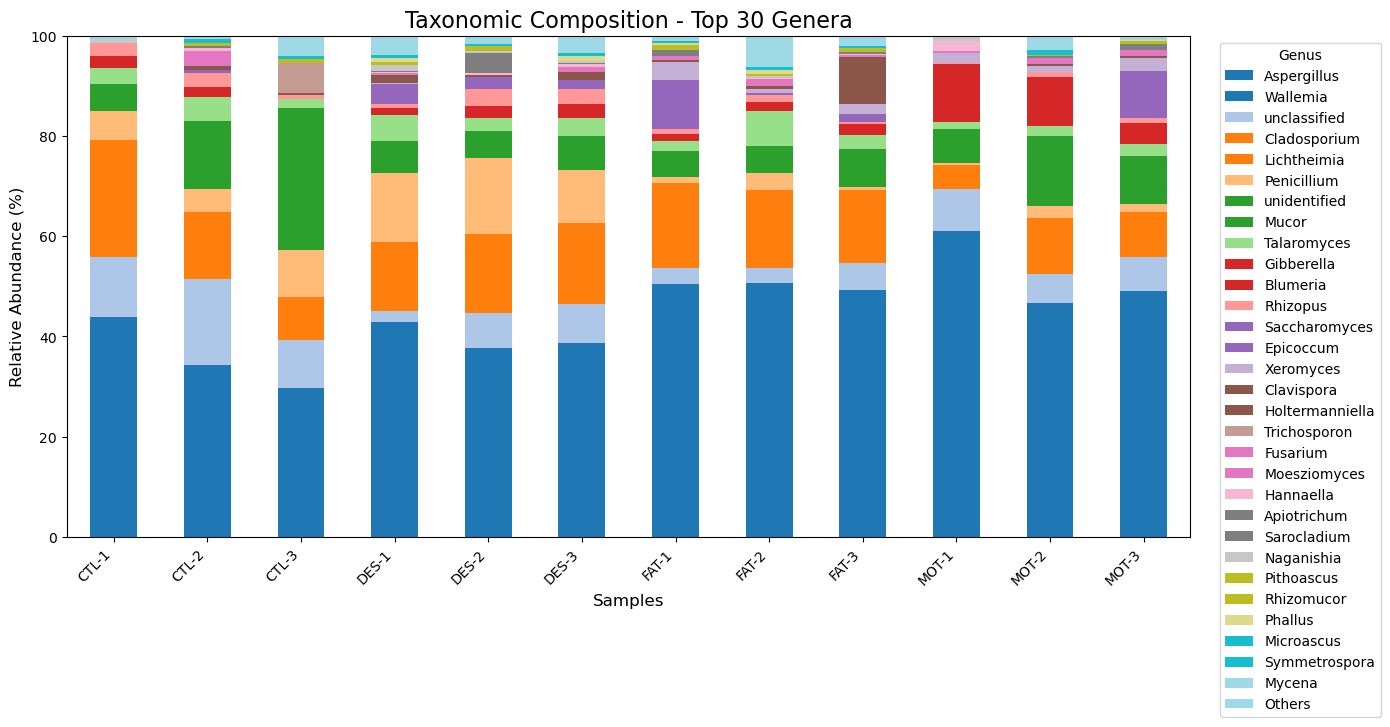

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths (loading the saved tables)
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')

# Load the counts matrix (index_col=0 keeps the sample names as rows)
counts_rarefied = pd.read_csv(counts_path, index_col=0)

# 2. Define OUTPUT directory for plots
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots'
os.makedirs(plot_dir, exist_ok=True)

# 3. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 4. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 5. Create a new dataframe with Top 10 and group the rest into 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# Sort samples alphabetically
plot_df = plot_df.sort_index()

# 6. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')

# Formatting the plot
plt.title(f'Taxonomic Composition - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 7. Save the plot in PNG and SVG
plot_path_png = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.png')
plot_path_svg = os.path.join(plot_dir, f'taxonomic_composition_top{top_n}.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot in the notebook
plt.show()

## Separation of the samples by groups

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots


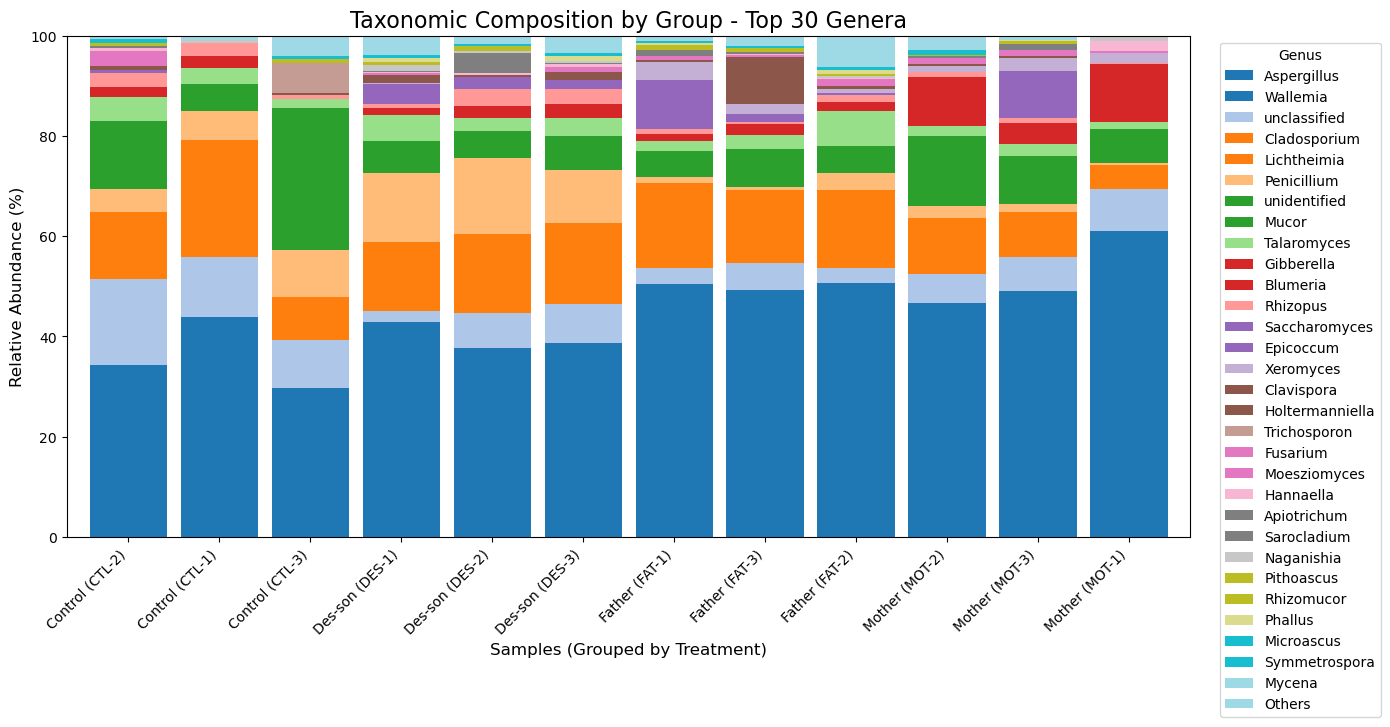

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# 2. Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# 3. IMPORTANT: Define your group column name here!
# Replace 'Treatment' with the exact column name from your metadata
group_col = 'Group'

# Sort metadata by the group column
meta_sorted = meta_df.sort_values(by=[group_col])

# Create a new label combining Group and Sample Name (e.g., "CTL (CTL-3)")
new_labels = meta_sorted[group_col].astype(str) + " (" + meta_sorted.index + ")"

# 4. Convert absolute counts to relative abundance (percentages)
rel_abund = counts_rarefied.div(counts_rarefied.sum(axis=1), axis=0) * 100

# 5. Identify the Top 10 most abundant genera
top_n = 30
top_genera = rel_abund.mean().nlargest(top_n).index

# 6. Create plot dataframe with Top 10 and 'Others'
plot_df = rel_abund[top_genera].copy()
plot_df['Others'] = rel_abund.drop(columns=top_genera).sum(axis=1)

# 7. Reorder plot_df to match the sorted metadata
plot_df = plot_df.loc[meta_sorted.index]
# Apply the new grouped labels to the X-axis
plot_df.index = new_labels

# 8. Define OUTPUT directory
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots'
os.makedirs(plot_dir, exist_ok=True)

# 9. Plot Stacked Bar Chart
ax = plot_df.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20', width=0.85)

# Formatting the plot
plt.title(f'Taxonomic Composition by Group - Top {top_n} Genera', fontsize=16)
plt.ylabel('Relative Abundance (%)', fontsize=12)
plt.xlabel('Samples (Grouped by Treatment)', fontsize=12)
plt.legend(title='Genus', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 10. Save the plot
plot_path_png = os.path.join(plot_dir, 'taxonomic_composition_grouped.png')
plot_path_svg = os.path.join(plot_dir, 'taxonomic_composition_grouped.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")
plt.show()

## Beta diversity analysis

/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:164: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(


PERMANOVA Results:
Pseudo-F: 3.4025
p-value:  0.0010

Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots


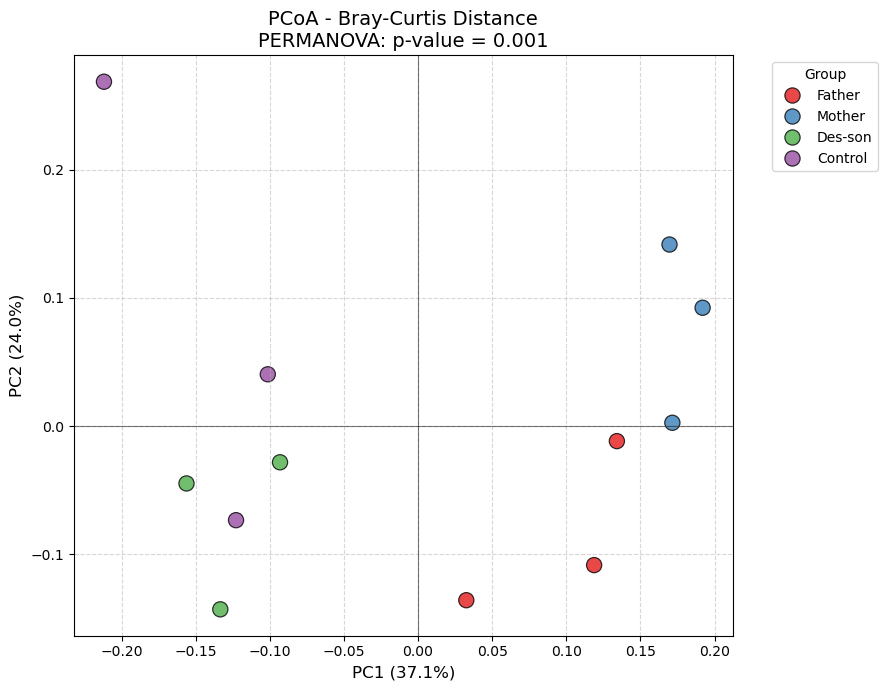

In [23]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import permanova

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# IMPORTANT: Define your group column name here!
group_col = 'Group'

# 2. Calculate Bray-Curtis Distance Matrix
# We use .values to pass the raw numbers, and pass the sample names as ids
bc_dm = beta_diversity("braycurtis", counts_rarefied.values, ids=counts_rarefied.index)

# 3. Perform PCoA (Principal Coordinate Analysis)
bc_pcoa = pcoa(bc_dm)

# Extract the coordinates for PC1 and PC2
pcoa_df = bc_pcoa.samples[['PC1', 'PC2']].copy()
# Join with metadata to get the group labels for coloring the plot
pcoa_df = pcoa_df.join(meta_df[[group_col]])

# Extract the percentage of variance explained by each axis
prop_expl = bc_pcoa.proportion_explained

# 4. Perform PERMANOVA (Statistical test for Beta Diversity)
perm_result = permanova(bc_dm, meta_df, column=group_col, permutations=999)
p_val = perm_result['p-value']
pseudo_f = perm_result['test statistic']

print(f"PERMANOVA Results:")
print(f"Pseudo-F: {pseudo_f:.4f}")
print(f"p-value:  {p_val:.4f}\n")

# 5. Plot the PCoA
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue=group_col, 
    data=pcoa_df, 
    s=120,          # Marker size
    alpha=0.8,      # Transparency
    palette='Set1', # Color palette
    edgecolor='black'
)

# Formatting the plot
plt.title(f'PCoA - Bray-Curtis Distance\nPERMANOVA: p-value = {p_val:.3f}', fontsize=14)
plt.xlabel(f"PC1 ({prop_expl['PC1']*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({prop_expl['PC2']*100:.1f}%)", fontsize=12)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5) # X axis line
plt.axvline(0, color='black', linewidth=0.8, alpha=0.5) # Y axis line
plt.tight_layout()

# 6. Save the plot
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots'
os.makedirs(plot_dir, exist_ok=True)

plot_path_png = os.path.join(plot_dir, 'pcoa_bray_curtis.png')
plot_path_svg = os.path.join(plot_dir, 'pcoa_bray_curtis.svg')

plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
plt.savefig(plot_path_svg, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_dir}")

# Display the plot
plt.show()

## Alpha diversity analysis

Plotting order will be: ['CTL', 'FAT', 'MOT', 'DES']


/home/marcos/miniconda3/lib/python3.13/site-packages/skbio/util/_warning.py:42: DeprecationWarning: `observed_otus` was renamed to `sobs` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)
/tmp/ipykernel_40256/3294766582.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], palette=palette, order=group_order, showfliers=False)
/tmp/ipykernel_40256/3294766582.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], palette=palette, order=group_order, showfliers=False)


Plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots/alpha_diversity_boxplots.png


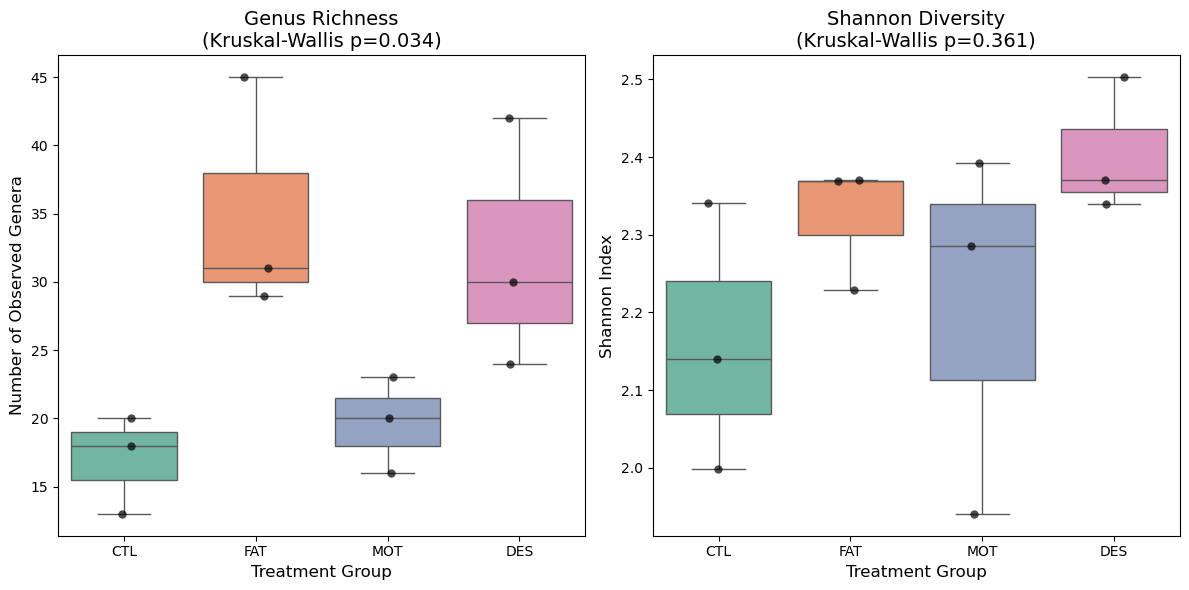

In [24]:
import os
import pandas as pd
import skbio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

# 1. Define INPUT paths
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots'

counts_path = os.path.join(stats_dir, 'rarefied_genus_counts.csv')
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

# Load the tables
counts_rarefied = pd.read_csv(counts_path, index_col=0)
meta_df = pd.read_csv(meta_path, index_col=0)

# Dynamically extract group names from the sample prefixes
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
groups = list(meta_df['Group'].unique())

# --- NEW: Define the specific order of the groups for the plot ---
control_group = 'CTL'
# This creates a list with 'CTL' first, followed by the rest
group_order = [control_group] + [g for g in groups if g != control_group]
print(f"Plotting order will be: {group_order}")
# -----------------------------------------------------------------

# 2. Calculate Alpha Diversity
meta_df['Observed_Genera'] = skbio.diversity.alpha_diversity('observed_otus', counts_rarefied.values, counts_rarefied.index)
meta_df['Shannon_Index'] = skbio.diversity.alpha_diversity('shannon', counts_rarefied.values, counts_rarefied.index)

# 3. Statistical Test (Global Kruskal-Wallis)
group_data_obs = [meta_df[meta_df['Group'] == g]['Observed_Genera'] for g in group_order]
group_data_sha = [meta_df[meta_df['Group'] == g]['Shannon_Index'] for g in group_order]

stat_obs, p_obs = kruskal(*group_data_obs)
stat_sha, p_sha = kruskal(*group_data_sha)

# 4. Plot Alpha Diversity (Boxplots)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Palette matching the number of groups
palette = sns.color_palette("Set2", len(group_order))

# Plot 1: Richness (Observed Genera)
sns.boxplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Observed_Genera', data=meta_df, ax=axes[0], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[0].set_title(f'Genus Richness\n(Kruskal-Wallis p={p_obs:.3f})', fontsize=14)
axes[0].set_ylabel('Number of Observed Genera', fontsize=12)
axes[0].set_xlabel('Treatment Group', fontsize=12)

# Plot 2: Shannon Diversity
sns.boxplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], palette=palette, order=group_order, showfliers=False)
sns.stripplot(x='Group', y='Shannon_Index', data=meta_df, ax=axes[1], color='black', alpha=0.7, jitter=True, size=6, order=group_order)
axes[1].set_title(f'Shannon Diversity\n(Kruskal-Wallis p={p_sha:.3f})', fontsize=14)
axes[1].set_ylabel('Shannon Index', fontsize=12)
axes[1].set_xlabel('Treatment Group', fontsize=12)

plt.tight_layout()

# 5. Save the plots
plot_path_png = os.path.join(plot_dir, 'alpha_diversity_boxplots.png')
plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')

print(f"Plot successfully saved to:\n{plot_path_png}")
plt.show()

## Differential abundance analysis

In [25]:
import os
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/4_emu_taxa/otu_abundance_matrix.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/its/6_plots'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)

# 2. Load RAW Matrix and Metadata
otu_df = pd.read_csv(matrix_path)
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_raw = otu_df.drop(columns=[c for c in tax_cols if c != 'genus'])
counts_raw = counts_raw.groupby('genus').sum(numeric_only=True).T
meta_df = pd.read_csv(meta_path, index_col=0)
counts_raw = counts_raw.loc[meta_df.index]

# 3. Dynamically extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]
unique_groups = meta_df['Group'].unique()

print(f"Setup complete. Detected groups: {unique_groups}")

# Generate all unique pairs of groups (combinations of 2)
all_pairs = list(combinations(unique_groups, 2))
print(f"Total comparisons to run: {len(all_pairs)}\n")

# Prepare relative abundance with pseudocount
counts_pseudo = counts_raw + 1
rel_abund = counts_pseudo.div(counts_pseudo.sum(axis=1), axis=0)

# 4. Loop through all pairs
for group1, group2 in all_pairs:
    print(f"=========================================")
    print(f"Testing: {group1} vs {group2}")
    
    samples_g1 = meta_df[meta_df['Group'] == group1].index
    samples_g2 = meta_df[meta_df['Group'] == group2].index
    
    df_g1 = rel_abund.loc[samples_g1]
    df_g2 = rel_abund.loc[samples_g2]
    
    results = []
    for genus in rel_abund.columns:
        stat, p_val = mannwhitneyu(df_g1[genus], df_g2[genus], alternative='two-sided')
        mean_g1 = df_g1[genus].mean()
        mean_g2 = df_g2[genus].mean()
        
        # Log2FC > 0 means increased in Group2. Log2FC < 0 means increased in Group1.
        log2fc = np.log2(mean_g2 / mean_g1)
        
        results.append({
            'Genus': genus,
            f'Mean_{group1}': mean_g1,
            f'Mean_{group2}': mean_g2,
            'Log2FC': log2fc,
            'p_value': p_val
        })

    da_df = pd.DataFrame(results).set_index('Genus').dropna()
    
    # FDR Correction
    da_df['FDR_q_value'] = multipletests(da_df['p_value'], method='fdr_bh')[1]
    
    # Filter Significant
    significant_genera = da_df[(da_df['FDR_q_value'] < 0.05) & (da_df['Log2FC'].abs() > 1)].copy()
    significant_genera = significant_genera.sort_values(by='Log2FC', ascending=False)
    
    # Save CSV for this pair
    da_out_path = os.path.join(stats_dir, f'differential_abundance_{group2}_vs_{group1}.csv')
    da_df.to_csv(da_out_path)
    
    # Plot if significant results exist
    if significant_genera.empty:
        print(f"No significant genera found for {group1} vs {group2}.\n")
    else:
        print(f"Found {len(significant_genera)} significant genera! Generating plot...\n")
        
        plt.figure(figsize=(10, max(4, len(significant_genera) * 0.4)))
        
        # Colors: Green if enriched in group2, Red if enriched in group1
        colors = ['#2ca02c' if x > 0 else '#d62728' for x in significant_genera['Log2FC']]
        
        sns.barplot(x=significant_genera['Log2FC'], y=significant_genera.index, palette=colors)
        
        plt.title(f'Differentially Abundant Genera\nGreen = Enriched in {group2} | Red = Enriched in {group1}', fontsize=14)
        plt.xlabel(f'Log2 Fold Change ({group2} / {group1})', fontsize=12)
        plt.ylabel('Genus', fontsize=12)
        plt.axvline(0, color='black', linewidth=1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        
        plot_path_png = os.path.join(plot_dir, f'da_barplot_{group2}_vs_{group1}.png')
        plt.savefig(plot_path_png, dpi=300, bbox_inches='tight')
        plt.close() # Close plot to prevent massive notebook scrolling

Setup complete. Detected groups: <StringArray>
['FAT', 'MOT', 'DES', 'CTL']
Length: 4, dtype: str
Total comparisons to run: 6

Testing: FAT vs MOT
No significant genera found for FAT vs MOT.

Testing: FAT vs DES
No significant genera found for FAT vs DES.

Testing: FAT vs CTL
No significant genera found for FAT vs CTL.

Testing: MOT vs DES
No significant genera found for MOT vs DES.

Testing: MOT vs CTL
No significant genera found for MOT vs CTL.

Testing: DES vs CTL
No significant genera found for DES vs CTL.

